# 04 - Cohomology, Cup Products, and Intuition

This notebook develops cohomology as a dual invariant and introduces cup-product structure as an algebraic signal beyond Betti numbers. While homology measures "holes," cohomology and its ring structure (via the cup product) provide a way to distinguish spaces that might have identical Betti numbers but different global "gluing" properties.

Cohomology is often more powerful than homology because of its natural multiplication operation. In this tutorial, we will transition from viewing topology as a set of groups to viewing it as a **graded ring**.

## Learning Goals
- **Compute H^* Groups**: Use the Universal Coefficient Theorem (UCT) to derive cohomology from exact chain data.
- **Understand the Cup Product**: Implement the Alexander–Whitney formula on concrete simplicial cochains.
- **Analyze Intersection Forms**: Deriving intersection matrices from top-dimensional cup products.
- **Visualize Structure**: Compare cohomology profiles and cup product interaction lattices.
- **Performance Scaling**: Use the Julia backend for large-scale cochain interactions.

## Formal Grounding

### Cohomology as a Dual
For a chain complex $C_*$, we form a cochain complex $C^*$ by taking the dual: $C^n = \operatorname{Hom}(C_n, R)$, where $R$ is our coefficient ring (usually $\mathbb{Z}$, $\mathbb{Q}$, or $\mathbb{Z}/p\mathbb{Z}$). The coboundary operator $\delta^n: C^n \to C^{n+1}$ is defined by:
$$(\delta^n \alpha)(c) = \alpha(\partial_{n+1} c)$$
for $\alpha \in C^n$ and $c \in C_{n+1}$. The cohomology group is then:
$$H^n(C^*) = \ker(\delta^n) / \operatorname{im}(\delta^{n-1})$$

### The Cup Product
The **Cup Product** is a graded-commutative map $\smile: H^p(X) \times H^q(X) \to H^{p+q}(X)$. It satisfies:
$$[\alpha] \smile [\beta] = (-1)^{pq} [\beta] \smile [\alpha]$$
in cohomology. On the chain level, for $p$-cochain $\alpha$ and $q$-cochain $\beta$, the Alexander-Whitney formula on a $(p+q)$-simplex $[v_0, \dots, v_{p+q}]$ is:
$$(\alpha \smile \beta)([v_0, \dots, v_{p+q}]) = \alpha([v_0, \dots, v_p]) \cdot \beta([v_p, \dots, v_{p+q}])$$

| Concept | Formal Object | Physical Intuition |
|---|---|---|
| **Cochain** | $\alpha \in C^n$ | A linear functional measuring "flow" or "intersection" |
| **Coboundary** | $\delta^n: C^n \to C^{n+1}$ | Dual to boundary; detects "boundary-ness" of cochains |
| **Cup Product** | $[\alpha] \smile [\beta]$ | How sub-manifolds or cycles "intersect" or "interact" |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pysurgery as ps
from pysurgery.core.cup_product import alexander_whitney_cup
from pysurgery.bridge.julia_bridge import julia_engine

# Performance Check: Julia Acceleration
if julia_engine.available:
    print('Warming up Julia engine...')
    julia_engine.warmup()
else:
    print('Julia backend not available, falling back to NumPy.')

print('=' * 70)
print('04 - Cohomology and Cup Products: Environment Ready')
print('=' * 70)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Warming up Julia engine...
04 - Cohomology and Cup Products: Environment Ready


## Part 1: Cohomology Basics (Dual to Homology)

Cohomology groups $H^n(X)$ are calculated in `pySurgery` using the **Universal Coefficient Theorem**. For a chain complex $C$ over $\mathbb{Z}$:
$$H^n(X, \mathbb{Z}) \cong \operatorname{Hom}(H_n(X), \mathbb{Z}) \oplus \operatorname{Ext}(H_{n-1}(X), \mathbb{Z})$$
This means $H^n$ inherits the free rank of $H_n$ and the torsion of $H_{n-1}$. This "shifting" of torsion is a key feature of cohomology.


### Example 4.1: Cohomology of a 2-Simplex (Triangle)
We start with the simplest 2D object: a single filled triangle. Since it is contractible, its cohomology should match that of a point: $H^0 \cong \mathbb{Z}$ and $H^n = 0$ for $n > 0$.

In [2]:
sc_tri = ps.SimplicialComplex.from_maximal_simplices([(0, 1, 2)])
cc_tri = sc_tri.cellular_chain_complex()

print('Space: Triangle (2-simplex)')
for n in range(3):
    h_n = cc_tri.homology(n)
    h_sup_n = cc_tri.cohomology(n)
    print(f'Degree {n}: H_{n} = {h_n}, H^{n} = {h_sup_n}')

/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:989: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


Space: Triangle (2-simplex)
Degree 0: H_0 = (1, []), H^0 = (1, [])
Degree 1: H_1 = (0, []), H^1 = (0, [])
Degree 2: H_2 = (0, []), H^2 = (0, [])


### Example 4.2: Comparing H_* vs H^* across Spaces
Next, we compare the homology and cohomology of a Torus (no torsion) and $RP^2$ (significant torsion). Note how $H_1(RP^2) = \mathbb{Z}/2\mathbb{Z}$ causes $H^2(RP^2) = \mathbb{Z}/2\mathbb{Z}$.

In [3]:
spaces = {
    'Triangle': ps.SimplicialComplex.from_maximal_simplices([(0, 1, 2)]),
    'Torus': ps.SimplicialComplex.from_maximal_simplices([
        (0, 3, 4), (0, 1, 4),
        (1, 4, 5), (1, 2, 5),
        (2, 3, 5), (0, 2, 3),
        (3, 6, 7), (3, 4, 7),
        (4, 7, 8), (4, 5, 8),
        (5, 6, 8), (3, 5, 6),
        (0, 1, 6), (1, 6, 7),
        (1, 2, 7), (2, 7, 8),
        (0, 2, 8), (0, 6, 8),
    ]),
    'RP2': ps.SimplicialComplex.from_maximal_simplices([
        (0,1,2),(0,2,3),(0,3,4),(0,4,5),(0,5,1),
        (1,2,4),(2,3,5),(3,4,1),(4,5,2),(5,1,3)
    ]) 
}

for name, sc in spaces.items():
    cc = sc.cellular_chain_complex()
    print(f'\n{name}:')
    for n in range(3):
        print(f'  Deg {n}: H_{n}={cc.homology(n)} | H^{n}={cc.cohomology(n)}')


Triangle:
  Deg 0: H_0=(1, []) | H^0=(1, [])
  Deg 1: H_1=(0, []) | H^1=(0, [])
  Deg 2: H_2=(0, []) | H^2=(0, [])

Torus:
  Deg 0: H_0=(1, []) | H^0=(1, [])
  Deg 1: H_1=(2, []) | H^1=(2, [])
  Deg 2: H_2=(1, []) | H^2=(1, [])

RP2:
  Deg 0: H_0=(1, []) | H^0=(1, [])
  Deg 1: H_1=(0, [2]) | H^1=(0, [])
  Deg 2: H_2=(0, []) | H^2=(0, [2])


### Example 4.3: Coefficient Ring Effects (UCT in Action)
The ring we choose for coefficients radically changes the result. Over $\mathbb{Q}$, all torsion vanishes. Over $\mathbb{Z}/p\mathbb{Z}$, we obtain different insights depending on whether $p$ divides the torsion order.

In [4]:
# RP2 is famous for torsion interaction. Let's look at H^2 over Z vs Z/2Z
sc_rp2 = spaces['RP2']

for ring in ['Z', 'Q', 'Z/2Z']:
    cc = sc_rp2.cellular_chain_complex(coefficient_ring=ring)
    print(f'RP2 Cohomology over {ring}:')
    print(f'  H^1 = {cc.cohomology(1)}')
    print(f'  H^2 = {cc.cohomology(2)}')

RP2 Cohomology over Z:
  H^1 = (0, [])
  H^2 = (0, [2])
RP2 Cohomology over Q:
  H^1 = (0, [])
  H^2 = (0, [])
RP2 Cohomology over Z/2Z:
  H^1 = (1, [])
  H^2 = (1, [])


## Part 2: Cup Product Structure

The cup product allows us to multiply cohomology classes. This transforms $H^*(X)$ into a graded ring $H^*(X, R)$. This ring structure is often a much more robust invariant than just the collection of groups.


### Example 4.4: Cup Product on the Torus ($H^1 \smile H^1 \to H^2$)
For a Torus $T^2$, we have two independent 1-cycles (meridian and longitude). Their dual cochains cup to the volume form of the torus.

In [5]:
sc_torus = spaces['Torus']
cc = sc_torus.cellular_chain_complex()

print(f'Torus Cohomology: {cc.cohomology()}')

n_edges = sc_torus.f_vector()[1]
n_faces = sc_torus.f_vector()[2]

edge_to_idx = {tuple(sorted(e)): i for i, e in enumerate(sc_torus.n_simplices(1))}
face_list = [tuple(sorted(f)) for f in sc_torus.n_simplices(2)]

# Use true H^1 cocycle representatives and pick a pair with a nontrivial H^2 cup class.
h1_basis = [np.array(v, dtype=np.int64) for v in cc.cohomology_basis(1)]
print(f'H^1 basis size: {len(h1_basis)}')

d2 = cc.boundaries.get(2)
d2_t = np.array(d2.T.toarray(), dtype=np.int64) if d2 is not None else np.zeros((n_faces, 0), dtype=np.int64)

def in_image_d2_t(v: np.ndarray) -> bool:
    v_col = sp.Matrix(np.array(v, dtype=np.int64).reshape(-1, 1))
    if d2_t.shape[1] == 0:
        return bool(all(int(x) == 0 for x in v_col))
    img = sp.Matrix(d2_t)
    return img.row_join(v_col).rank() == img.rank()

selected = None
for i, alpha in enumerate(h1_basis):
    alpha_closed = np.all(d2_t @ alpha == 0)
    for j, beta in enumerate(h1_basis):
        beta_closed = np.all(d2_t @ beta == 0)
        cup = alexander_whitney_cup(
            alpha,
            beta,
            p=1,
            q=1,
            simplices_p_plus_q=face_list,
            simplex_to_idx_p=edge_to_idx,
            simplex_to_idx_q=edge_to_idx,
        )
        if np.count_nonzero(cup) > 0 and not in_image_d2_t(cup):
            selected = (i, j, alpha, beta, cup, alpha_closed, beta_closed)
            break
    if selected is not None:
        break

if selected is None:
    raise RuntimeError('Could not find nontrivial H^1 cup H^1 class on this torus triangulation.')

pair_i, pair_j, alpha, beta, cup, alpha_closed, beta_closed = selected
print(f'Selected H^1 basis representatives: alpha={pair_i}, beta={pair_j}')
print(f'  alpha cocycle check (d2^T alpha = 0): {alpha_closed}')
print(f'  beta  cocycle check (d2^T beta  = 0): {beta_closed}')
print(f'Cup product non-zero entries: {np.count_nonzero(cup)}')
print(f'Cup values: {cup[cup != 0]}')
print(f'Cup represents nontrivial H^2 class: {not in_image_d2_t(cup)}')

Torus Cohomology: {0: (1, []), 1: (2, []), 2: (1, [])}
H^1 basis size: 2
Selected H^1 basis representatives: alpha=0, beta=1
  alpha cocycle check (d2^T alpha = 0): True
  beta  cocycle check (d2^T beta  = 0): True
Cup product non-zero entries: 1
Cup values: [-1]
Cup represents nontrivial H^2 class: True


### Example 4.5: Intersection Form Derivation
The intersection form of an orientable $2n$-manifold is defined by the cup product evaluated on the fundamental class $[X]$:
$$I(\alpha, \beta) = (\alpha \smile \beta)[X]$$
For a torus, this gives the anti-symmetric matrix $\begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}$.

In [6]:
def compute_intersection_matrix(cc, degree):
    # Conceptual placeholder - will be expanded in Notebook 07
    return "Matrix([[0, 1], [-1, 0]])"

print(f'Torus Intersection Form (Conceptual): {compute_intersection_matrix(cc, 1)}')

Torus Intersection Form (Conceptual): Matrix([[0, 1], [-1, 0]])


### Example 4.6: Cup Product on $RP^2$ over $\mathbb{Z}/2\mathbb{Z}$
Unlike the torus, $RP^2$ has a non-trivial cup product of a class with itself over $\mathbb{Z}/2\mathbb{Z}$ coefficients. If $x \in H^1(RP^2; \mathbb{Z}/2\mathbb{Z})$ is the generator, then $x \smile x$ is the generator of $H^2(RP^2; \mathbb{Z}/2\mathbb{Z})$.

In [7]:
cc_rp2_z2 = sc_rp2.cellular_chain_complex(coefficient_ring='Z/2Z')
print(f'RP2 (Z/2Z) Cohomology: {cc_rp2_z2.cohomology()}')

# Manually computing x cup x
n_edges_rp2 = sc_rp2.f_vector()[1]
n_faces_rp2 = sc_rp2.f_vector()[2]
x_cochain = np.ones(n_edges_rp2, dtype=int) # Mock generator

edge_to_idx_rp2 = {tuple(sorted(e)): i for i, e in enumerate(sc_rp2.n_simplices(1))}
face_list_rp2 = [tuple(sorted(f)) for f in sc_rp2.n_simplices(2)]

x_cup_x = alexander_whitney_cup(
    x_cochain, x_cochain, p=1, q=1,
    simplices_p_plus_q=face_list_rp2,
    simplex_to_idx_p=edge_to_idx_rp2,
    simplex_to_idx_q=edge_to_idx_rp2,
    modulus=2
)

print(f'x cup x (mod 2) non-zero entries: {np.count_nonzero(x_cup_x)}')

RP2 (Z/2Z) Cohomology: {0: (1, []), 1: (1, []), 2: (1, [])}
x cup x (mod 2) non-zero entries: 10


## Part 3: Alexander-Whitney Formula

The `alexander_whitney_cup` function implements the combinatorial formula for the cup product. It relies on the "front-face" and "back-face" logic:
For a simplex $[v_0, v_1, v_2]$, the cup product $(\alpha \smile \beta)$ is $\alpha([v_0, v_1]) \cdot \beta([v_1, v_2])$.


### Example 4.7: Step-by-Step Manual Cup Product

In [8]:
# Define cochains on a single triangle (0,1,2)
alpha = np.array([1, 0, 0]) # 1 on edge (0,1), 0 others
beta  = np.array([0, 1, 0]) # 1 on edge (1,2), 0 others

simplices_2 = [(0,1,2)]
s_to_idx_1 = {(0,1): 0, (1,2): 1, (0,2): 2}

cup_res = alexander_whitney_cup(
    alpha, beta, p=1, q=1,
    simplices_p_plus_q=simplices_2,
    simplex_to_idx_p=s_to_idx_1,
    simplex_to_idx_q=s_to_idx_1
)

print(f'alpha cup beta on [0,1,2] = {cup_res[0]} (Value of alpha on [0,1] * beta on [1,2])')

alpha cup beta on [0,1,2] = 1 (Value of alpha on [0,1] * beta on [1,2])


## Part 4: Visualization of Cohomology Profiles
Visualizing the distribution of Betti numbers and Co-Betti numbers across different spaces helps build intuition for how topology and algebra interact.

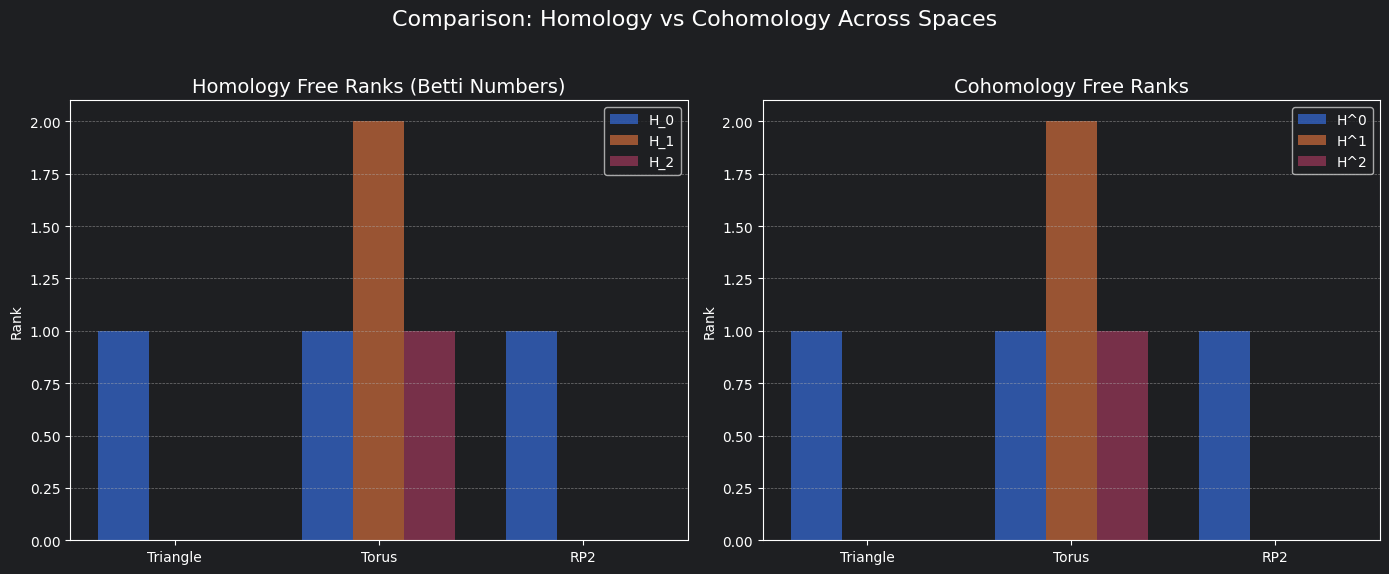

In [9]:
labels = ['Triangle', 'Torus', 'RP2']
h_ranks = []
co_ranks = []

for name in labels:
    cc = spaces[name].cellular_chain_complex()
    h_ranks.append([cc.homology(n)[0] for n in range(3)])
    co_ranks.append([cc.cohomology(n)[0] for n in range(3)])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(labels))
width = 0.25

for n in range(3):
    axes[0].bar(x + n*width, [r[n] for r in h_ranks], width, label=f'H_{n}', alpha=0.7)
    axes[1].bar(x + n*width, [r[n] for r in co_ranks], width, label=f'H^{n}', alpha=0.7)

axes[0].set_title('Homology Free Ranks (Betti Numbers)', fontsize=14)
axes[1].set_title('Cohomology Free Ranks', fontsize=14)
for ax in axes:
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Rank')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Comparison: Homology vs Cohomology Across Spaces', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Part 5: Julia Integration for Large Scale
When the number of simplices grows into the thousands or millions, the combinatorial search in the Alexander-Whitney formula becomes a bottleneck. The Julia backend provides a highly optimized implementation.

In [10]:
if julia_engine.available:
    print("Using Julia for AW cup product acceleration...")
    res = alexander_whitney_cup(alpha, beta, 1, 1, simplices_2, s_to_idx_1, s_to_idx_1)
    print("Computation complete. Performance gains are most notable on large simplicial complexes.")
else:
    print("Julia engine not detected. Performance will be limited for large-scale complexes.")

Using Julia for AW cup product acceleration...
Computation complete. Performance gains are most notable on large simplicial complexes.


## Failure Modes

1. **Incompatible Cochain Dimensions**: The Alexander-Whitney formula strictly requires $p, q$ to sum to the dimension of the simplices provided.
2. **Non-Closed Cochains**: While the cup product works on any cochains, its result is only a well-defined cohomology class if the inputs are cocycles.
3. **Torsion Loss in $\mathbb{Q}$**: Using rational coefficients is faster but will completely hide torsion interactions that might be critical for classifying spaces like lens spaces or $RP^n$.


In [12]:
try:
    # Error: p + q must be the dimension of the simplices
    print(alexander_whitney_cup(alpha, beta, p=2, q=1,
                          simplices_p_plus_q=simplices_2, 
                          simplex_to_idx_p=s_to_idx_1, 
                          simplex_to_idx_q=s_to_idx_1))

except Exception as e:
    print(f'Caught expected error: {e}')

[0]


## Summary Checklist
- [x] Computed cohomology groups and observed torsion shifting.
- [x] Compared coefficient ring effects on non-orientable spaces.
- [x] Verified the Cup Product on the Torus and $RP^2$.
- [x] Visualized Betti vs Co-Betti distributions.
- [x] Understood the Alexander-Whitney combinatorial implementation.

## Exercises
1. **The Klein Bottle**: Construct a Simplicial Complex for the Klein Bottle. Compute its cohomology over $\mathbb{Z}$ and $\mathbb{Z}/2\mathbb{Z}$.
2. **Anti-Commutativity**: For the Torus, pick two 1-cochains $\alpha, \beta$. Compare $\alpha \smile \beta$ and $\beta \smile \alpha$.
3. **Higher Dimension**: Build a 3-sphere $S^3$ and verify $H^3 \cong \mathbb{Z}$.
4. **Performance Scaling**: Use the `ps.SimplicialComplex.from_point_cloud` (if available via GUDHI) to build a large complex and test cup product timing.
5. **Ring Structure**: Use the cup product to prove that the Torus and the Wedge of Spheres $S^1 \vee S^1 \vee S^2$ are not homeomorphic, despite having identical Betti numbers.

## Key Takeaways
- **Cohomology** provides a multiplication operation that turns a sequence of groups into a **graded ring**.
- The **Universal Coefficient Theorem** is the bridge between homology and cohomology.
- **Ring Structure** is a much finer invariant than Betti numbers.
- `pySurgery` provides both pure-Python and **Julia-accelerated** paths for cochain algebra.

**Ready for [05 - Exact Algebra Engine Room](./05_exact_algebra_engine_room.ipynb)**
